# Direction AUROC Comparison

Loads pre-computed AUROC from saved `.pt` direction files (no GPU required).
Produces a single combined figure showing discriminative power of SyA, GA,
and SyPr directions across candidate layers for 8B and 3.3-70B models,
with the layers used in downstream framing evaluations highlighted.

In [6]:
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path
from collections import defaultdict

%matplotlib inline

In [7]:
DIRECTIONS_ROOT = Path("directions")
RESULTS_DIR = Path("results")

MODEL_SPECS = {
    "8B": {
        "dir": DIRECTIONS_ROOT / "8b",
        "selected_layer": 24,
        "full_name": "Llama 3.1 8B Instruct",
    },
    "3.3-70B": {
        "dir": DIRECTIONS_ROOT / "3.3-70b",
        "selected_layer": 60,
        "full_name": "Llama 3.3 70B Instruct",
    },
}

BEHAVIOR_META = {
    "sya":  {"label": "SyA", "color": "#d62728", "full": "Sycophantic Agreement"},
    "ga":   {"label": "GA",  "color": "#1f77b4", "full": "Genuine Agreement"},
    "sypr": {"label": "SyPr","color": "#2ca02c", "full": "Sycophantic Praise"},
}

In [8]:
def load_all_directions():
    """Load metadata from all direction .pt files, grouped by model."""
    records = []
    for model_label, spec in MODEL_SPECS.items():
        for pt_file in sorted(spec["dir"].glob("*.pt")):
            saved = torch.load(str(pt_file), weights_only=False)
            records.append({
                "model": model_label,
                "behavior": saved["behavior"],
                "layer": saved["layer"],
                "auroc": saved["auroc"],
                "n_examples": saved.get("n_examples"),
                "method": saved.get("method", "unknown"),
                "pool": saved.get("pool_strategy", "unknown"),
                "svd_var": saved.get("svd_variance_explained"),
                "file": pt_file.name,
                "selected": saved["layer"] == spec["selected_layer"],
            })
    return records

records = load_all_directions()
print(f"Loaded {len(records)} direction files")

Loaded 18 direction files


## Summary table

Filter to comparable directions: SVD-aggregated, ≥2000 examples (the `n2k7_svd` generation).

In [9]:
comparable = [
    r for r in records
    if "svd" in r["method"] and r.get("n_examples") and r["n_examples"] >= 2000
]

print(f"{'Model':<10} {'Beh':<5} {'Layer':<6} {'AUROC':>7} {'SVD var%':>9} "
      f"{'Pool':<8} {'Selected':>8}")
print("-" * 62)
for model in ["8B", "3.3-70B"]:
    recs = sorted(
        [r for r in comparable if r["model"] == model],
        key=lambda r: (r["behavior"], r["layer"]),
    )
    for r in recs:
        svd = f"{r['svd_var']:.1%}" if r["svd_var"] else "\u2014"
        sel = "  \u2605" if r["selected"] else ""
        print(f"{model:<10} {r['behavior'].upper():<5} {r['layer']:<6} "
              f"{r['auroc']:>7.4f} {svd:>9} {r['pool']:<8}{sel}")
    print()

Model      Beh   Layer    AUROC  SVD var% Pool     Selected
--------------------------------------------------------------
8B         GA    24      0.9894         — pre_eos   ★
8B         SYA   24      0.9242         — pre_eos   ★
8B         SYPR  24      0.8698         — pre_eos   ★

3.3-70B    GA    55      0.9507     47.7% eos     
3.3-70B    GA    60      0.9480     46.2% eos       ★
3.3-70B    GA    65      0.9467     45.3% eos     
3.3-70B    SYA   55      0.9479     43.2% eos     
3.3-70B    SYA   60      0.9476     42.3% eos       ★
3.3-70B    SYA   65      0.9452     41.1% eos     
3.3-70B    SYPR  55      0.7653     57.7% eos     
3.3-70B    SYPR  60      0.7625     57.5% eos       ★
3.3-70B    SYPR  65      0.7662     57.7% eos     



## AUROC comparison plot

Saved: results/direction_comparison/auroc_comparison.png


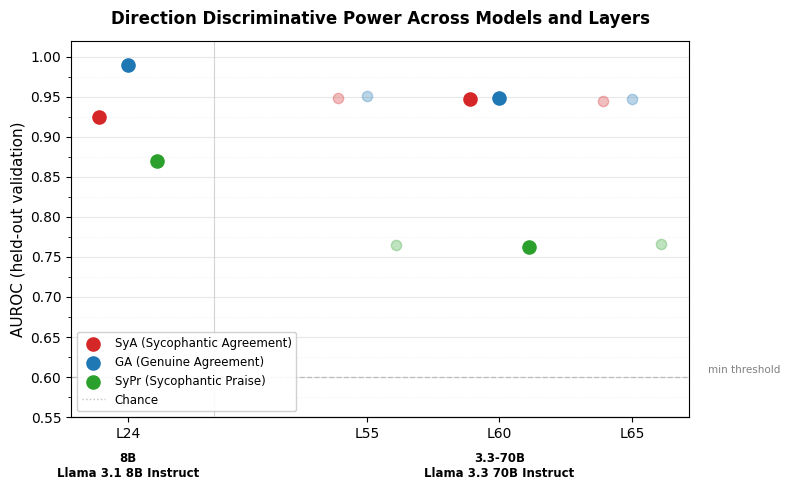

In [10]:
groups = defaultdict(list)
for r in comparable:
    groups[r["model"]].append(r)

ordered_models = ["8B", "3.3-70B"]
x_labels = []
x_positions = []
model_boundaries = []
pos = 0
model_centers = {}

for model in ordered_models:
    model_recs = groups[model]
    layers = sorted(set(r["layer"] for r in model_recs))
    start = pos
    for layer in layers:
        x_labels.append(f"L{layer}")
        x_positions.append(pos)
        pos += 1
    model_centers[model] = (start + pos - 1) / 2
    model_boundaries.append(pos - 0.5)
    pos += 0.8

behaviors = ["sya", "ga", "sypr"]
n_beh = len(behaviors)
dot_width = 0.22
offsets = np.linspace(-dot_width * (n_beh - 1) / 2,
                       dot_width * (n_beh - 1) / 2, n_beh)

fig, ax = plt.subplots(figsize=(8, 5))

for beh_idx, beh in enumerate(behaviors):
    meta = BEHAVIOR_META[beh]
    beh_recs = [r for r in comparable if r["behavior"] == beh]

    sel_xs, sel_ys = [], []
    unsel_xs, unsel_ys = [], []
    idx = 0
    for model in ordered_models:
        model_recs = [r for r in beh_recs if r["model"] == model]
        layers = sorted(set(r["layer"] for r in groups[model]))
        for layer in layers:
            match = [r for r in model_recs if r["layer"] == layer]
            if match:
                r = match[0]
                x = x_positions[idx] + offsets[beh_idx]
                y = r["auroc"]
                if r["selected"]:
                    sel_xs.append(x)
                    sel_ys.append(y)
                else:
                    unsel_xs.append(x)
                    unsel_ys.append(y)
            idx += 1

    if unsel_xs:
        ax.scatter(unsel_xs, unsel_ys, color=meta["color"], s=55, zorder=3,
                   alpha=0.3)
    ax.scatter(sel_xs, sel_ys, color=meta["color"], s=90, zorder=4,
               label=f'{meta["label"]} ({meta["full"]})', alpha=1.0)

ax.axhline(0.5, color="grey", ls=":", lw=1, alpha=0.5, label="Chance")
MIN_AUROC = 0.6
ax.axhline(MIN_AUROC, color="grey", ls="--", lw=1, alpha=0.4)
ax.text(x_positions[-1] + offsets[-1] + 0.35, MIN_AUROC + 0.003,
        "min threshold", fontsize=7.5, color="grey", va="bottom")

for boundary in model_boundaries[:-1]:
    ax.axvline(boundary + 0.15, color="lightgrey", ls="-", lw=0.8)

ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels, fontsize=10)

ax.set_ylabel("AUROC (held-out validation)", fontsize=11)
ax.set_title("Direction Discriminative Power Across Models and Layers",
             fontsize=12, fontweight="bold", pad=12)

ax.set_ylim(0.55, 1.02)
ax.yaxis.set_major_locator(plt.MultipleLocator(0.05))
ax.yaxis.set_minor_locator(plt.MultipleLocator(0.025))
ax.grid(axis="y", alpha=0.3, which="major")
ax.grid(axis="y", alpha=0.15, which="minor", ls=":")

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=labels, loc="lower left",
          fontsize=8.5, framealpha=0.9)

ax2 = ax.secondary_xaxis("bottom")
ax2.set_xticks([model_centers[m] for m in ordered_models])
ax2.set_xticklabels([f"\n\n{m}\n{MODEL_SPECS[m]['full_name']}"
                     for m in ordered_models],
                    fontsize=8.5, fontweight="bold")
ax2.tick_params(length=0)

fig.tight_layout()

out_dir = RESULTS_DIR / "direction_comparison"
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "auroc_comparison.png"
fig.savefig(str(out_path), dpi=200, bbox_inches="tight")
print(f"Saved: {out_path}")

plt.show()